# Ce que les débitmètres disent tout seuls

Les trois carnets précédents simulent. Celui-ci ne simule rien : il fait des **soustractions**
entre des mesures.

L'idée est simple. Si l'on connaît tout ce qui entre dans une portion de réseau, tout ce qui y est
consommé, et ce qu'elle stocke, alors ce qui manque à l'appel **fuit**. Encore faut-il une portion
de réseau dont toute la frontière est mesurée.

Sur L-Town il y en a exactement une : la **zone C**.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from calibration import reseau as R, ameliorations as A

plt.rcParams.update({"figure.figsize": (10, 3.2), "figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 9})

ANNEE = 2018
R.verifier_donnees(ANNEE)
wn = R.charger_modele(duree_h=24)
debits = R.charger_debits(ANNEE)
niveau = R.charger_niveau(ANNEE)
print("prêt")

prêt


## 1. Pourquoi la zone C et pas le reste

La zone C est alimentée **uniquement** par le réservoir T1, lui-même rempli **uniquement** par la
pompe. Sa frontière compte donc trois instruments, et ils existent tous :

* le **débitmètre de la pompe**, pour ce qui entre ;
* le **capteur de niveau** de T1, pour ce qui est stocké ;
* les **82 compteurs**, pour ce qui est consommé.

Le reste du réseau n'a que ses deux débitmètres d'entrée, et aucun compteur.

In [2]:
zones = R.zones(wn)
amr = R.charger_amr(ANNEE)
n_c = [n for n, z in zones.items() if z == "C"]

print(f"zone C : {len(n_c)} jonctions, dont {sum(n in amr.columns for n in n_c)} équipées d'un compteur")
print(f"zone A+B : {sum(z == 'AB' for z in zones.values())} jonctions, "
      f"{sum(n in amr.columns for n, z in zones.items() if z == 'AB')} équipées")

zone C : 92 jonctions, dont 82 équipées d'un compteur
zone A+B : 690 jonctions, 0 équipées


## 2. Ce qui entre en zone C

Ce n'est pas le débit de la pompe : une partie de ce qu'elle envoie reste dans le réservoir. Ce
qui passe réellement vers la zone C, c'est

$$ Q_{\text{entrée}} = Q_{\text{pompe}} - A \cdot \frac{\mathrm{d}h}{\mathrm{d}t} $$

avec $A$ la section du réservoir et $h$ son niveau, lu au capteur.

In [3]:
section = R.section_reservoir(wn)
dh = niveau.diff().shift(-1)                     # variation du niveau sur le pas suivant
entre_c = debits["PUMP_1"] - section * dh / (R.PAS_MIN / 60.0)

print(f"section du réservoir : {section:.0f} m²")
print(f"débit de la pompe    : {debits['PUMP_1'].mean():.1f} m³/h en moyenne")
print(f"entrée en zone C     : {entre_c.mean():.1f} m³/h en moyenne")

section du réservoir : 201 m²
débit de la pompe    : 26.8 m³/h en moyenne
entrée en zone C     : 26.8 m³/h en moyenne


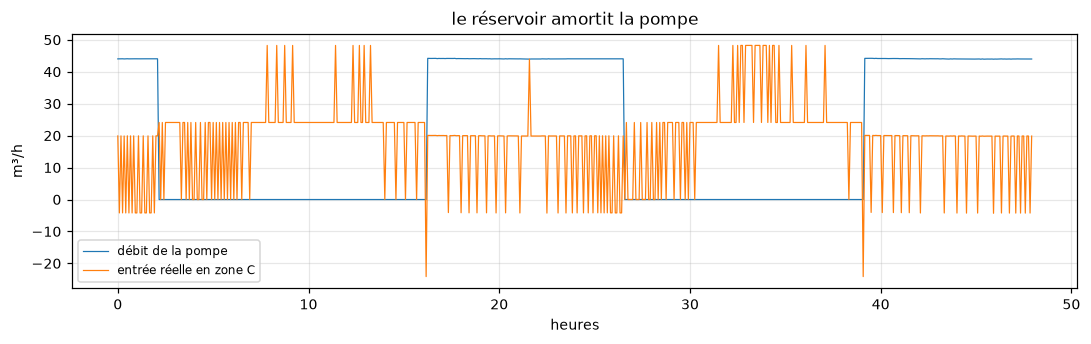

In [4]:
# Sur deux jours : la pompe est tout ou rien, l'entrée en zone C ne l'est pas.
j = slice(0, 2 * R.PAS_JOUR)
h = np.arange(2 * R.PAS_JOUR) / R.PAS_JOUR * 24

fig, ax = plt.subplots()
ax.plot(h, debits["PUMP_1"].to_numpy()[j], lw=0.8, label="débit de la pompe")
ax.plot(h, entre_c.to_numpy()[j], lw=0.8, label="entrée réelle en zone C")
ax.set_xlabel("heures"); ax.set_ylabel("m³/h"); ax.legend(fontsize=8)
ax.set_title("le réservoir amortit la pompe")
fig.tight_layout()

Le réservoir fait son travail : la pompe fonctionne par à-coups, la zone C reçoit un débit lissé.
Sur l'année les deux moyennes coïncident — 26,8 m³/h — ce qui est le contrôle qu'on attend : le
réservoir finit l'année au niveau où il l'a commencée, donc il n'a rien stocké net.

C'est aussi la première mauvaise nouvelle. Le capteur de niveau n'a que **deux décimales**, et on
multiplie sa différence par 201 m² : un centimètre d'arrondi vaut déjà 24 m³/h au pas de
5 minutes. On y revient au §6.

## 3. Ce qui y est consommé

Les 82 compteurs couvrent 82 des 92 jonctions. Pour les dix autres, on extrapole au prorata de la
demande nominale du fichier — c'est ce que fait `demande_c_estimee`.

In [5]:
bases = R.bases_nominales(wn).sum(axis=1)
sans_compteur = [n for n in n_c if n not in amr.columns]

print(f"demande nominale des {len(amr.columns)} jonctions équipées   : {bases[list(amr.columns)].sum():.2f} m³/h")
print(f"demande nominale des {len(sans_compteur)} jonctions non équipées : {bases[sans_compteur].sum():.2f} m³/h")
print(f"facteur d'extrapolation : ×{bases[n_c].sum() / bases[list(amr.columns)].sum():.4f}")

consomme_c = A.demande_c_estimee(wn, ANNEE)
print(f"\nconsommation de la zone C : {consomme_c.mean():.2f} m³/h en moyenne")

demande nominale des 82 jonctions équipées   : 17.74 m³/h
demande nominale des 10 jonctions non équipées : 1.84 m³/h
facteur d'extrapolation : ×1.1038



consommation de la zone C : 19.43 m³/h en moyenne


## 4. Ce qui reste, c'est la fuite

In [6]:
fuite_c = entre_c - consomme_c
print(f"fuite estimée en zone C : {fuite_c.mean():.2f} m³/h en moyenne sur l'année")
print(f"soit {fuite_c.mean() / entre_c.mean():.0%} de ce qui entre dans la zone\n")
print("moyennes mensuelles, m³/h :")
print(fuite_c.resample("ME").mean().round(2).to_string())

fuite estimée en zone C : 7.41 m³/h en moyenne sur l'année
soit 28% de ce qui entre dans la zone

moyennes mensuelles, m³/h :
temps
2018-01-31     2.72
2018-02-28     6.77
2018-03-31     6.77
2018-04-30     6.81
2018-05-31     6.83
2018-06-30     6.79
2018-07-31    11.90
2018-08-31    12.73
2018-09-30     6.85
2018-10-31     6.86
2018-11-30     6.88
2018-12-31     6.85
Freq: ME


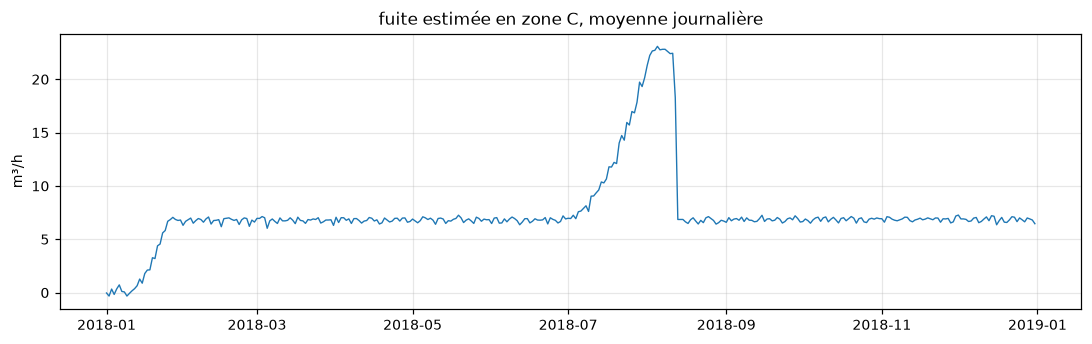

In [7]:
fig, ax = plt.subplots()
ax.plot(fuite_c.resample("D").mean(), lw=0.9)
ax.set_ylabel("m³/h"); ax.set_title("fuite estimée en zone C, moyenne journalière")
fig.tight_layout()

### Lecture

Deux paliers, et une marche nette entre les deux. On n'a rien simulé et rien supposé : c'est une
soustraction entre trois instruments.

Reste à savoir si c'est **juste**.

## 5. Le contrôle : est-ce que ça retrouve les vraies fuites ?

Le jeu de données publie les fuites qu'il contient, conduite par conduite. On ne s'en est servi à
aucun moment du calcul — uniquement ici, pour vérifier.

Deux des quatorze conduites fuyardes de 2018 sont à l'intérieur de la zone C.

conduites fuyardes situées en zone C : ['p31', 'p257']


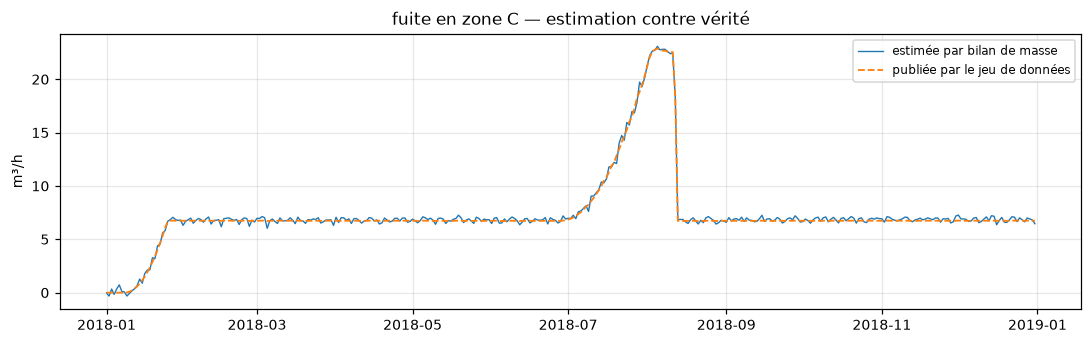

In [8]:
fuites = R.charger_fuites(ANNEE)
en_c = [p for p in fuites.columns
        if zones.get(wn.get_link(p).start_node_name) == "C"
        and zones.get(wn.get_link(p).end_node_name) == "C"]
publiee = fuites[en_c].sum(axis=1)
print("conduites fuyardes situées en zone C :", en_c)

fig, ax = plt.subplots()
ax.plot(fuite_c.resample("D").mean(), lw=0.9, label="estimée par bilan de masse")
ax.plot(publiee.resample("D").mean(), lw=1.2, ls="--", label="publiée par le jeu de données")
ax.set_ylabel("m³/h"); ax.legend(fontsize=8)
ax.set_title("fuite en zone C — estimation contre vérité")
fig.tight_layout()

In [9]:
e = fuite_c.resample("D").mean()
v = publiee.resample("D").mean()
print(f"corrélation            : {e.corr(v):.4f}")
print(f"décalage moyen (biais) : {(e - v).mean():+.2f} m³/h")
print(f"bruit (écart-type)     : {(e - v).std():.2f} m³/h")

corrélation            : 0.9981
décalage moyen (biais) : +0.08 m³/h
bruit (écart-type)     : 0.23 m³/h


### Lecture

**Le bilan retrouve les fuites publiées presque exactement** : corrélation 0,998, biais de
0,08 m³/h, bruit de 0,23 m³/h sur des moyennes journalières.

Autrement dit, on dispose d'un **débitmètre de fuite** pour la zone C, construit uniquement avec
des mesures, sans modèle hydraulique et sans connaître la réponse.

## 6. À quelle finesse peut-on lire ?

Tout dépend de la durée sur laquelle on moyenne, à cause de l'arrondi du capteur de niveau.

In [10]:
lignes = []
for lib, regle in [("5 minutes", None), ("1 heure", "h"), ("1 jour", "D"), ("1 semaine", "W")]:
    a = fuite_c if regle is None else fuite_c.resample(regle).mean()
    b = publiee if regle is None else publiee.resample(regle).mean()
    lignes.append({"moyenné sur": lib, "biais (m³/h)": (a - b).mean(),
                   "bruit (m³/h)": (a - b).std(),
                   "plus petite fuite lisible à 3σ": 3 * (a - b).std()})
print(pd.DataFrame(lignes).round(2).to_string(index=False))

moyenné sur  biais (m³/h)  bruit (m³/h)  plus petite fuite lisible à 3σ
  5 minutes          0.08         10.36                           31.07
    1 heure          0.08          1.96                            5.87
     1 jour          0.08          0.23                            0.68
  1 semaine          0.07          0.08                            0.23


### Lecture

Le bruit vient presque entièrement de l'arrondi du capteur de niveau, et il se moyenne : 31 m³/h
au pas de 5 minutes, **0,7 m³/h sur une journée**, 0,2 sur une semaine. La marche de juillet en
fait 5, soit une vingtaine d'écarts-types journaliers.

Comparons avec le carnet 3, qui cherchait la même chose dans les **pressions**. Là, une fuite de
10 m³/h produisait de 8,9 à 99,5 cm de baisse selon l'endroit, pour une erreur de modèle de
8,3 cm. Ramené au seuil : il fallait de **0,8 à 9 m³/h** pour être visible, selon la conduite.

Les deux routes se valent donc au meilleur endroit — mais le bilan de masse donne **0,7 m³/h
partout dans la zone C**, sans dépendre de la distance au capteur, et sans demander le moindre
modèle calibré.

## 7. Et la zone A+B ?

On aimerait faire pareil. Les deux débitmètres d'entrée donnent tout ce qui entre dans le réseau,
et on vient de calculer ce qui part vers la zone C. La différence sort donc forcément par A+B.

In [11]:
sortie_ab = debits["p227"] + debits["p235"] - entre_c
fuite_ab_publiee = fuites[[p for p in fuites.columns if p not in en_c]].sum(axis=1)

print(f"tout ce qui sort par A+B   : {sortie_ab.mean():.1f} m³/h")
print(f"  dont fuites (publiées)   : {fuite_ab_publiee.mean():.1f} m³/h  "
      f"({fuite_ab_publiee.mean() / sortie_ab.mean():.0%})")
print(f"  dont consommation réelle : {sortie_ab.mean() - fuite_ab_publiee.mean():.1f} m³/h")

tout ce qui sort par A+B   : 174.9 m³/h
  dont fuites (publiées)   : 18.2 m³/h  (10%)
  dont consommation réelle : 156.7 m³/h


**Et c'est là que ça s'arrête.** Cette différence vaut « fuites **+** consommation », et rien dans
les données ne permet de séparer les deux termes : il n'y a aucun compteur dans la zone A+B.

On ne peut donc pas « retirer les fuites pour retrouver la consommation » — les fuites de A+B sont
précisément ce qu'on n'a pas. Le raisonnement tourne en rond.

La méthode classique pour s'en sortir est le **débit de nuit minimal** : vers 3 heures du matin la
consommation est au plus bas, donc ce qui coule encore est surtout de la fuite. Regardons ce que
ça vaut ici.

In [12]:
nuit = sortie_ab.between_time("02:00", "04:00").resample("D").min()
v_ab = fuite_ab_publiee.resample("D").mean()
t = pd.DataFrame({"nuit": nuit, "fuite": v_ab}).dropna()
pente, ordonnee = np.polyfit(t.fuite, t.nuit, 1)

print(f"corrélation débit de nuit / fuite publiée : {t.nuit.corr(t.fuite):.3f}")
print(f"régression : nuit = {pente:.2f} × fuite + {ordonnee:.0f}")
print(f"reste après régression : {(t.nuit - (pente * t.fuite + ordonnee)).std():.1f} m³/h de bruit")

corrélation débit de nuit / fuite publiée : 0.610
régression : nuit = 1.14 × fuite + 46
reste après régression : 24.7 m³/h de bruit


### Lecture

La pente vaut 1,1 : le débit de nuit **suit** bien la fuite, un mètre cube pour un mètre cube.
L'ordonnée à l'origine, 46 m³/h, est la consommation nocturne incompressible de la zone.

Mais le bruit résiduel est de **25 m³/h**, pour des fuites qui vont de 0 à 40. Le rapport signal
sur bruit est de l'ordre de 1 — contre 30 en zone C. La méthode fonctionne en principe et ne
tranche rien en pratique.

### Une conséquence directe pour le carnet 2

Le levier 4 du carnet 2 recale la demande de A+B sur ce même bilan de masse. On peut maintenant
chiffrer ce que cela absorbe : **18 m³/h de fuite, soit 10 % de la consommation**, reversés dans
la demande des 690 nœuds.

C'est sans conséquence pour calibrer un modèle hydraulique. C'est rédhibitoire si l'on compte
ensuite chercher des fuites dans le résidu de pression, puisqu'on vient de les y dissoudre.

## Ce qu'il faut retenir

1. **La zone C se décompose exactement** : entrée (pompe moins stock), consommation (compteurs),
   et le reste est la fuite. Biais 0,08 m³/h, bruit 0,23 m³/h sur des moyennes journalières.
2. **La sensibilité ne dépend pas de l'endroit.** 0,7 m³/h détectable partout dans la zone, quand
   la route par les pressions demande de 0,8 à 9 m³/h selon la distance au capteur le plus
   proche — et sans avoir à calibrer quoi que ce soit.
3. **La zone A+B ne se décompose pas.** Le bilan y donne « fuites + consommation » sans moyen de
   séparer, et le débit de nuit minimal, qui est la méthode classique, y a un rapport signal sur
   bruit de 1.
4. **Le découpage compte plus que la méthode.** La même soustraction donne un résultat exploitable
   sur 12 % du réseau et rien du tout sur les 88 % restants — la différence n'est pas dans le
   calcul, elle est dans l'emplacement des capteurs.